In [1]:
import gensim.downloader as api
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
# Tải model GloVe. Lần đầu tiên chạy sẽ mất một vài phút để tải về.
print("Đang tải model 'glove-wiki-gigaword-100'...")
model = api.load('glove-wiki-gigaword-100')
print("Tải model thành công!")

# Chọn một danh sách các từ để trực quan hóa
# Các từ này thuộc các nhóm ngữ nghĩa rõ ràng để dễ quan sát
words_to_plot = [
    # Nhóm 1: Hoàng gia
    'king', 'queen', 'prince', 'princess', 'royal',
    # Nhóm 2: Động vật
    'cat', 'dog', 'lion', 'tiger', 'animal',
    # Nhóm 3: Quốc gia
    'vietnam', 'japan', 'france', 'italy', 'country',
    # Nhóm 4: Công nghệ
    'computer', 'software', 'internet', 'phone', 'technology',
    # Nhóm 5: Thực phẩm
    'apple', 'banana', 'pizza', 'sushi', 'food'
]

word_vectors = np.array([model[word] for word in words_to_plot])

Đang tải model 'glove-wiki-gigaword-100'...
Tải model thành công!


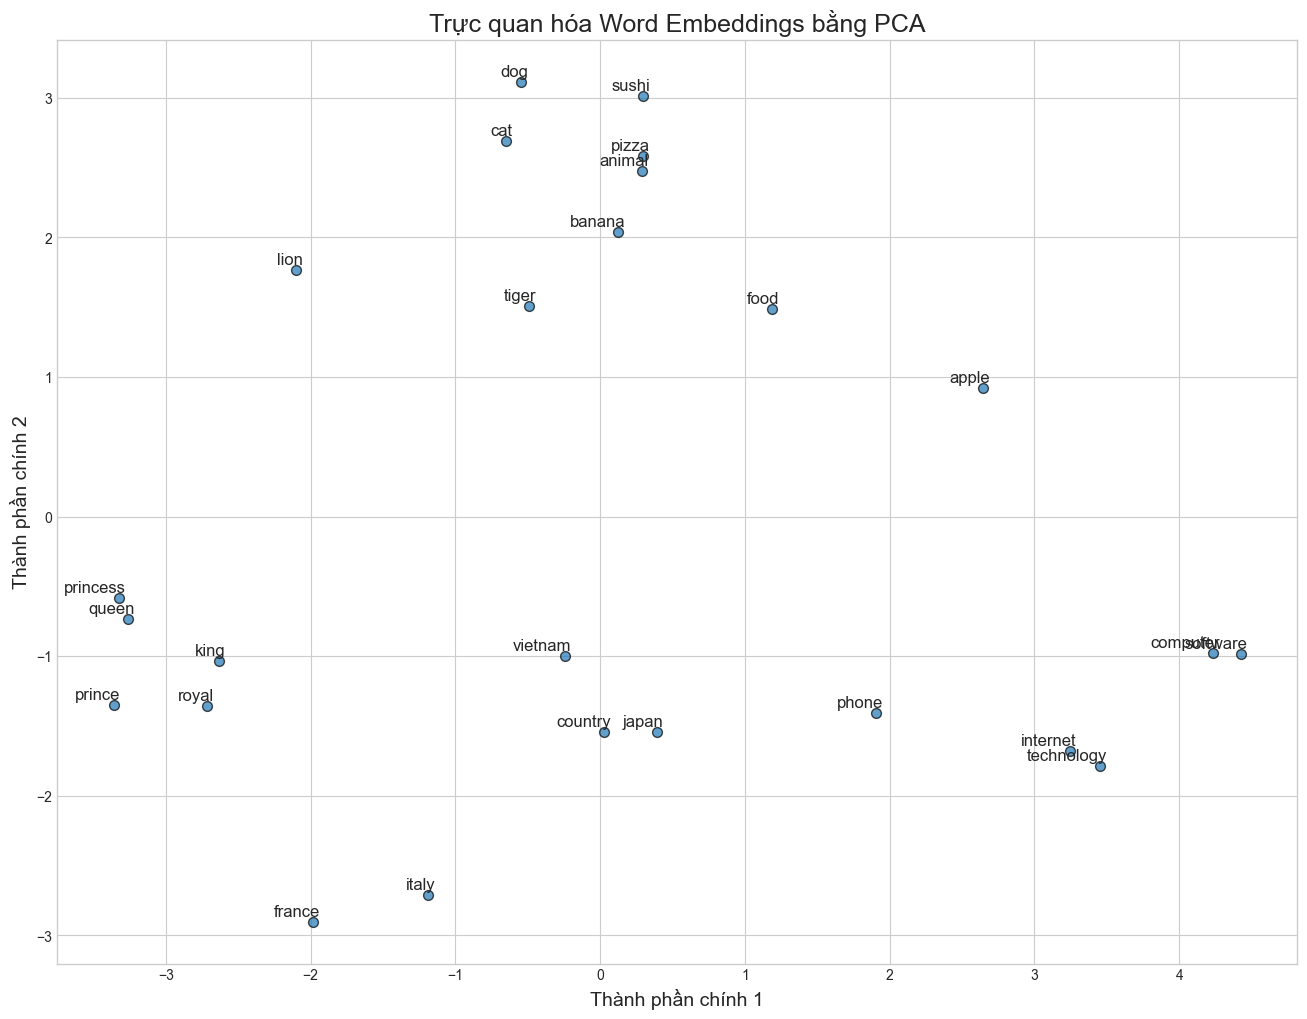

In [3]:
# Khởi tạo PCA để giảm xuống 2 chiều
pca = PCA(n_components=2)

# Fit và transform dữ liệu
vectors_2d_pca = pca.fit_transform(word_vectors)

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(16, 12))

# Vẽ các điểm vector
plt.scatter(vectors_2d_pca[:, 0], vectors_2d_pca[:, 1], s=50, alpha=0.7, edgecolors='k')

# Gắn nhãn cho từng điểm
for i, word in enumerate(words_to_plot):
    plt.annotate(
        word,
        xy=(vectors_2d_pca[i, 0], vectors_2d_pca[i, 1]),
        xytext=(5, 2),
        textcoords='offset points',
        ha='right',
        va='bottom',
        fontsize=12
    )

plt.title('Trực quan hóa Word Embeddings bằng PCA', fontsize=18)
plt.xlabel('Thành phần chính 1', fontsize=14)
plt.ylabel('Thành phần chính 2', fontsize=14)
plt.show()

Đang chạy t-SNE...
t-SNE hoàn tất!


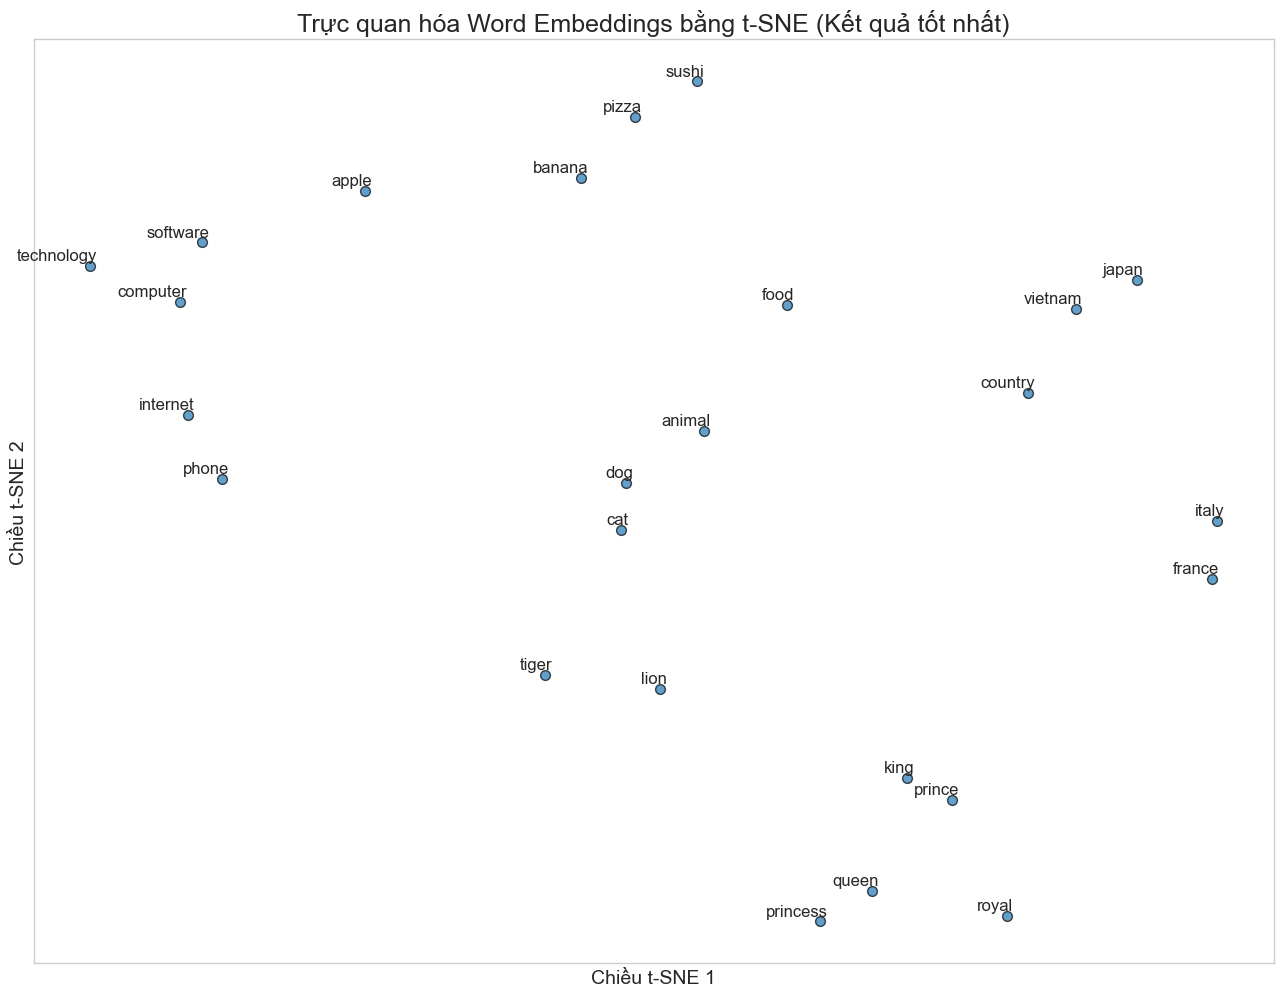

In [4]:
# Khởi tạo t-SNE để giảm xuống 2 chiều
# perplexity: Liên quan đến số lân cận gần nhất mà mỗi điểm xem xét. Giá trị phổ biến từ 5 đến 50.
# random_state: Để kết quả có thể tái tạo lại được.
tsne = TSNE(n_components=2, random_state=42, perplexity=15, n_iter=1000, learning_rate='auto', init='pca')

# Fit và transform dữ liệu (có thể mất một chút thời gian)
print("Đang chạy t-SNE...")
vectors_2d_tsne = tsne.fit_transform(word_vectors)
print("t-SNE hoàn tất!")

plt.figure(figsize=(16, 12))

# Vẽ các điểm vector
plt.scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], s=50, alpha=0.7, edgecolors='k')

# Gắn nhãn cho từng điểm
for i, word in enumerate(words_to_plot):
    plt.annotate(
        word,
        xy=(vectors_2d_tsne[i, 0], vectors_2d_tsne[i, 1]),
        xytext=(5, 2),
        textcoords='offset points',
        ha='right',
        va='bottom',
        fontsize=12
    )

plt.title('Trực quan hóa Word Embeddings bằng t-SNE (Kết quả tốt nhất)', fontsize=18)
plt.xlabel('Chiều t-SNE 1', fontsize=14)
plt.ylabel('Chiều t-SNE 2', fontsize=14)
plt.xticks([]) 
plt.yticks([])
plt.show()

In [5]:
# Giảm chiều xuống 3D bằng t-SNE
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=15, n_iter=1000, learning_rate='auto', init='pca')
print("Đang chạy t-SNE cho 3D...")
vectors_3d = tsne_3d.fit_transform(word_vectors)
print("Hoàn tất!")

# Tạo biểu đồ 3D
fig = go.Figure(data=[go.Scatter3d(
    x=vectors_3d[:, 0],
    y=vectors_3d[:, 1],
    z=vectors_3d[:, 2],
    mode='markers+text',
    marker=dict(
        size=5,
        color=vectors_3d[:, 2],  # Tô màu theo chiều Z
        colorscale='Viridis',
        opacity=0.8
    ),
    text=words_to_plot,
    textposition='top center'
)])

fig.update_layout(
    title='Trực quan hóa Word Embeddings trong không gian 3D (Tương tác)',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

Đang chạy t-SNE cho 3D...
Hoàn tất!
